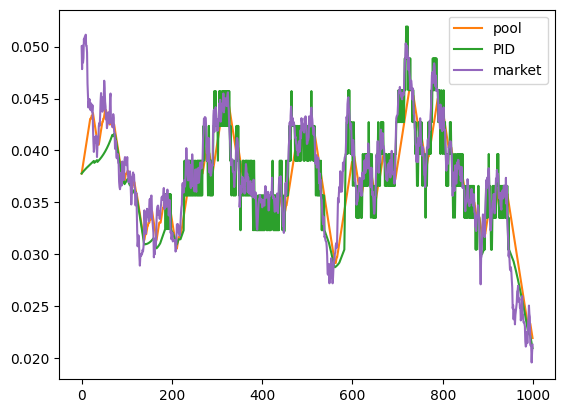

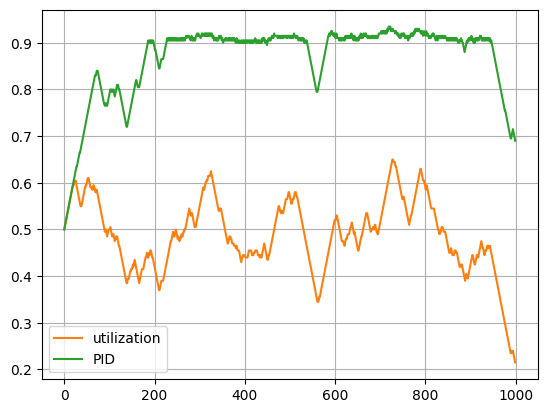

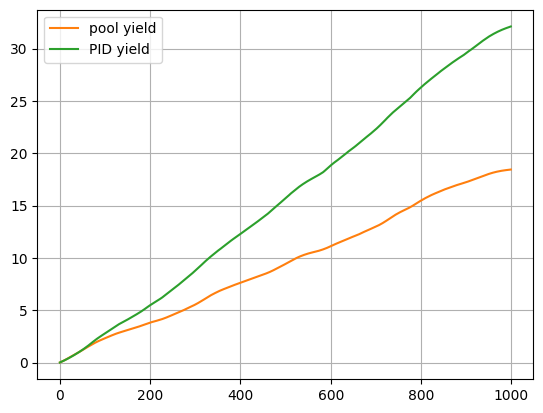

In [54]:
import matplotlib.pyplot as plt
import numpy as np


def bound(x, a, b):
    return max(a, min(x, b))


def kink(r0, r1, r2, u_opt, u):
    assert 0 <= u_opt <= 1
    assert 0 <= u <= 1

    r = r0
    if u <= u_opt:
        r += r1 * u / u_opt
    else:
        r += r1 + r2 * (u - u_opt) / (1 - u_opt)
    return r


def pid(r0, r1, r2, u_opt, u, prev_err):
    # Deadband - apply no change if |u - u_opt| <= e
    e = 0.05
    if abs(u - u_opt) <= e:
        return (r0, r1, r2, 0)

    # P
    k0 = 0.001
    # I
    k1 = 0
    # D
    k2 = 0

    r0 = r0

    r1 = r1

    err = u - u_opt
    d_err = err - prev_err
    
    r1 += k0 * err + k2 * d_err

    r1 = bound(r1, r0 + 0.001, 0.1)

    r2 = 3 * r1
    r2 = bound(r2, r1 + 0.001, 0.5)

    assert 0 < r0 < r1 < r2 <= 0.5

    return (r0, r1, r2, err)


T = 1000

### Market rates ###
m0 = 0.05
# Volatility
m_vol = 0.001
delta_m_rates = np.random.normal(0, m_vol, T)

### Pool rates ###
# Utilization rate
u0 = 0.5
r0 = 0.01
r1 = 0.05
r2 = 0.15
u_opt = 0.9

# Skip utilization rate change if 0 <= m - r <= E
E = 0.001

# Initial pool rate
u = u0
r = kink(r0, r1, r2, u_opt, u)

# PID controlled rate
c = r
c0 = r0
c1 = r1
c2 = r2
cu = u0
# cu - u_opt
err = 0

# Intial market rate
m = m0
m_rates = []

p_rates = []
u_rates = []

c_rates = []
cu_rates = []

# PID controller

for t in range(T):
    m_rates.append(m)
    p_rates.append(r)
    u_rates.append(u)

    c_rates.append(c)
    cu_rates.append(cu)

    # Utilization rate without PID controller
    # TODO: random du
    du = 0.005
    if m < r:
        # Less lend and borrow demand
        u -= du
    elif r + E <= m:
        # More lend and borrow demand
        u += du
    u = bound(u, 0, 1)

    # Utilization rate with PID controller
    # TODO: random du
    du = 0.005
    if m < c:
        # Less lend and borrow demand
        cu -= du
    elif c + E <= m:
        # More lend and borrow demand
        cu += du
    cu = bound(cu, 0, 1)

    # Pool rate without PID controller
    r = kink(r0, r1, r2, u_opt, u)

    # Pool rate with PID controller
    (c0, c1, c2, err) = pid(c0, c1, c2, u_opt, cu, err)
    c = kink(c0, c1, c2, u_opt, cu)

    m += delta_m_rates[t]
    m = bound(m, 0, 1)

### Yields ###
# Pool yield
y_p = np.cumsum([r * u for r, u in zip(p_rates, u_rates)])
# Pool yield with PID controller
y_c = np.cumsum([r * u for r, u in zip(c_rates, cu_rates)])

### Plots ###
# Rates
plt.figure()
plt.plot(p_rates, label="pool", color="tab:orange")
plt.plot(c_rates, label="PID", color="tab:green")
plt.plot(m_rates, label="market", color="tab:purple")
plt.legend()
plt.show()

# Utilization rates
plt.figure()
plt.plot(u_rates, label="utilization", color="tab:orange")
plt.plot(cu_rates, label="PID", color="tab:green")
plt.grid()
plt.legend()
plt.show()

# Yields
plt.figure()
plt.plot(y_p, label="pool yield", color="tab:orange")
plt.plot(y_c, label="PID yield", color="tab:green")
plt.grid()
plt.legend()
plt.show()